# Building a Decision Tree Classifier

CSI 4106 — Introduction to Artificial Intelligence

Marcel Turcotte  
2026-09-15

# Introduction

This notebook develops a small decision-tree classifier from first
principles. The objective is not to compete with scikit-learn, but to
expose the central operations of the learning algorithm:

1.  measure how mixed the classes are;
2.  evaluate candidate splits;
3.  retain the best split; and
4.  repeat recursively.

The implementation supports numerical features, binary threshold splits,
multiclass labels, class-probability predictions, and a few stopping
conditions. It deliberately omits missing values, categorical features,
sample weights, optimized split search, and pruning.

# Preparation

The only non-standard dataset dependency is `palmerpenguins`. The
installation step runs only when that package is unavailable, which
makes the notebook suitable for a fresh Google Colab session.

In [2]:
import subprocess
import sys
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

try:
    from palmerpenguins import load_penguins
except ImportError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "palmerpenguins"
    ])
    from palmerpenguins import load_penguins

from sklearn.model_selection import train_test_split

# Palmer Penguins

We retain two numerical features and formulate a binary classification
task: **Gentoo** versus **not Gentoo**. Limiting the example to two
features lets us draw the learned decision regions.

In [3]:
feature_names = ["bill_depth_mm", "body_mass_g"]

penguins = load_penguins()
penguins = penguins[feature_names + ["species"]].dropna().copy()

X = penguins[feature_names].to_numpy()
y = np.where(
    penguins["species"].to_numpy() == "Gentoo",
    "Gentoo",
    "Not Gentoo",
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training examples: {len(X_train)}")
print(f"Test examples: {len(X_test)}")

Training examples: 273
Test examples: 69

# Entropy

For a node containing class proportions $p_1,\ldots,p_K$, entropy is

$$
H=-\sum_{k=1}^{K}p_k\log_2p_k.
$$

A pure node has entropy zero. Entropy increases as the class proportions
become more evenly balanced.

In [4]:
def class_probabilities(y, classes):
    """Return the fraction of examples belonging to each class."""
    return np.array([np.mean(y == label) for label in classes])


def entropy(y, classes):
    """Measure how mixed the classes are; zero means a pure node."""
    probabilities = class_probabilities(y, classes)
    probabilities = probabilities[probabilities > 0]
    if len(probabilities) == 1:
        return 0.0
    return float(-np.sum(probabilities * np.log2(probabilities)))

The following small check recovers the familiar binary values: a
balanced node has one bit of entropy, whereas a pure node has none.

In [5]:
binary_classes = np.array(["Gentoo", "Not Gentoo"])

balanced = np.array(["Gentoo", "Not Gentoo"])
pure = np.array(["Gentoo", "Gentoo"])

print(f"Balanced node: {entropy(balanced, binary_classes):.3f} bits")
print(f"Pure node: {entropy(pure, binary_classes):.3f} bits")

Balanced node: 1.000 bits
Pure node: 0.000 bits

# Evaluating a Split

A candidate split creates left and right children. We score it using
their weighted entropy:

$$
J=
\frac{N_{\mathrm{left}}}{N_{\mathrm{parent}}}H_{\mathrm{left}}
+
\frac{N_{\mathrm{right}}}{N_{\mathrm{parent}}}H_{\mathrm{right}}.
$$

The weights prevent a tiny pure child from having the same influence as
a much larger mixed child.

In [6]:
def weighted_entropy(y_left, y_right, classes):
    """Return the weighted entropy produced by a split."""
    n_left = len(y_left)
    n_right = len(y_right)
    n_parent = n_left + n_right

    return (
        n_left / n_parent * entropy(y_left, classes)
        + n_right / n_parent * entropy(y_right, classes)
    )


def candidate_thresholds(values):
    """Return midpoints between consecutive distinct feature values."""
    values = np.unique(values)
    return (values[:-1] + values[1:]) / 2

## Three candidate splits

The following example compares the cases discussed in the lecture.
Without weights, isolating a single pure example appears deceptively
attractive.

In [7]:
split_examples = {
    "messy": (
        np.array(["Gentoo"] * 3 + ["Not Gentoo"] * 2),
        np.array(["Gentoo"] * 2 + ["Not Gentoo"] * 3),
    ),
    "isolate one": (
        np.array(["Gentoo"]),
        np.array(["Gentoo"] * 4 + ["Not Gentoo"] * 5),
    ),
    "useful": (
        np.array(["Gentoo"] * 4 + ["Not Gentoo"]),
        np.array(["Gentoo"] + ["Not Gentoo"] * 4),
    ),
}

for name, (left, right) in split_examples.items():
    unweighted = (
        entropy(left, binary_classes) + entropy(right, binary_classes)
    ) / 2
    weighted = weighted_entropy(left, right, binary_classes)
    print(f"{name:>11}: unweighted={unweighted:.3f}, weighted={weighted:.3f}")

      messy: unweighted=0.971, weighted=0.971
isolate one: unweighted=0.496, weighted=0.892
     useful: unweighted=0.722, weighted=0.722

# Greedy Split Search

For every feature, we examine the midpoints between consecutive distinct
values. The function retains the candidate with the smallest weighted
entropy.

In [8]:
def find_best_split(X, y, classes, min_samples_leaf):
    """Return the best split and the number of candidates evaluated."""
    best_split = None
    best_score = entropy(y, classes)
    n_candidates = 0

    for feature in range(X.shape[1]):
        for threshold in candidate_thresholds(X[:, feature]):
            go_left = X[:, feature] <= threshold
            n_left = np.sum(go_left)
            n_right = len(y) - n_left

            if min(n_left, n_right) < min_samples_leaf:
                continue

            n_candidates += 1
            score = weighted_entropy(y[go_left], y[~go_left], classes)
            if score < best_score:
                best_score = score
                best_split = (feature, float(threshold), go_left)

    return best_split, n_candidates

This is a greedy search: it chooses the best immediate split and does
not reconsider earlier decisions. It is therefore not guaranteed to
construct the smallest or globally optimal tree.

# Tree Representation

Each node stores the class proportions of the examples that reached it.
A leaf uses those proportions to make predictions. An internal node
additionally stores a feature, a threshold, and two children.

In [9]:
@dataclass
class Node:
    probabilities: np.ndarray
    n_samples: int
    loss: float
    feature: int | None = None
    threshold: float | None = None
    left: "Node | None" = None
    right: "Node | None" = None

    @property
    def is_leaf(self):
        return self.feature is None

# Classifier

The recursive `_grow_tree` method is the heart of learning. It creates a
node, checks the stopping conditions, finds a split, and recursively
constructs its children.

The validation and text-formatting methods are included for usability.
They are supporting code rather than new machine-learning ideas.

In [10]:
class SimpleDecisionTreeClassifier:
    """A didactic classifier with a small scikit-learn-like interface."""

    def __init__(
        self,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self._validate_training_data(X, y)

        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]
        self.n_candidate_splits_ = 0
        self.tree_ = self._grow_tree(X, y, depth=0)
        return self

    def _grow_tree(self, X, y, depth):
        probabilities = class_probabilities(y, self.classes_)
        node = Node(
            probabilities=probabilities,
            n_samples=len(y),
            loss=entropy(y, self.classes_),
        )

        depth_limit = self.max_depth is not None and depth >= self.max_depth
        pure_node = np.count_nonzero(probabilities) == 1
        too_small = len(y) < self.min_samples_split

        if pure_node or depth_limit or too_small:
            return node

        split, n_candidates = find_best_split(
            X, y, self.classes_, self.min_samples_leaf
        )
        self.n_candidate_splits_ += n_candidates
        if split is None:
            return node

        node.feature, node.threshold, go_left = split
        node.left = self._grow_tree(X[go_left], y[go_left], depth + 1)
        node.right = self._grow_tree(X[~go_left], y[~go_left], depth + 1)
        return node

    def _find_leaf(self, x):
        node = self.tree_
        while not node.is_leaf:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node

    def predict_proba(self, X):
        X = self._validate_prediction_data(X)
        return np.vstack([self._find_leaf(x).probabilities for x in X])

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[np.argmax(probabilities, axis=1)]

    def score(self, X, y):
        return float(np.mean(self.predict(X) == np.asarray(y)))

    def export_text(self, feature_names=None):
        if feature_names is None:
            feature_names = [f"x[{j}]" for j in range(self.n_features_in_)]
        if len(feature_names) != self.n_features_in_:
            raise ValueError("feature_names must match the number of features")

        lines = []

        def visit(node, indent):
            if node.is_leaf:
                prediction = self.classes_[np.argmax(node.probabilities)]
                if isinstance(prediction, np.generic):
                    prediction = prediction.item()
                probabilities = np.round(node.probabilities, 3)
                lines.append(
                    f"{indent}predict {prediction!r} "
                    f"(p={probabilities}, n={node.n_samples})"
                )
                return

            name = feature_names[node.feature]
            lines.append(f"{indent}if {name} <= {node.threshold:.3f}:")
            visit(node.left, indent + "    ")
            lines.append(f"{indent}else:")
            visit(node.right, indent + "    ")

        visit(self.tree_, "")
        return "\n".join(lines)

    def _validate_training_data(self, X, y):
        if X.ndim != 2 or y.ndim != 1 or len(X) != len(y):
            raise ValueError(
                "X must be 2-D and y must be 1-D with matching rows"
            )
        if len(y) == 0:
            raise ValueError("the training set cannot be empty")
        if not np.isfinite(X).all():
            raise ValueError(
                "missing and non-finite feature values are unsupported"
            )
        if self.max_depth is not None and self.max_depth < 0:
            raise ValueError("max_depth must be non-negative or None")
        if self.min_samples_split < 2:
            raise ValueError("min_samples_split must be at least 2")
        if self.min_samples_leaf < 1:
            raise ValueError("min_samples_leaf must be at least 1")

    def _validate_prediction_data(self, X):
        if not hasattr(self, "tree_"):
            raise ValueError("call fit before making predictions")
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if X.ndim != 2 or X.shape[1] != self.n_features_in_:
            raise ValueError("X has the wrong number of features")
        if not np.isfinite(X).all():
            raise ValueError(
                "missing and non-finite feature values are unsupported"
            )
        return X

# Training

We limit the tree to two decisions along any path and require each leaf
to contain at least five training examples.

In [11]:
tree_model = SimpleDecisionTreeClassifier(max_depth=2, min_samples_leaf=5)
tree_model.fit(X_train, y_train)

print(f"Test accuracy: {tree_model.score(X_test, y_test):.3f}")
print(f"Candidate splits evaluated: {tree_model.n_candidate_splits_}")
print(f"Class order: {tree_model.classes_}")
print("\nLearned rules:\n")
print(tree_model.export_text(feature_names))

Test accuracy: 1.000
Candidate splits evaluated: 312
Class order: ['Gentoo' 'Not Gentoo']

Learned rules:

if bill_depth_mm <= 16.450:
    if body_mass_g <= 3750.000:
        predict 'Not Gentoo' (p=[0. 1.], n=5)
    else:
        predict 'Gentoo' (p=[1. 0.], n=92)
else:
    if body_mass_g <= 5100.000:
        predict 'Not Gentoo' (p=[0. 1.], n=170)
    else:
        predict 'Gentoo' (p=[1. 0.], n=6)

# Decision Regions

Every test in this tree compares one feature with one threshold. In two
dimensions, the resulting regions are therefore assembled from
horizontal and vertical boundaries.

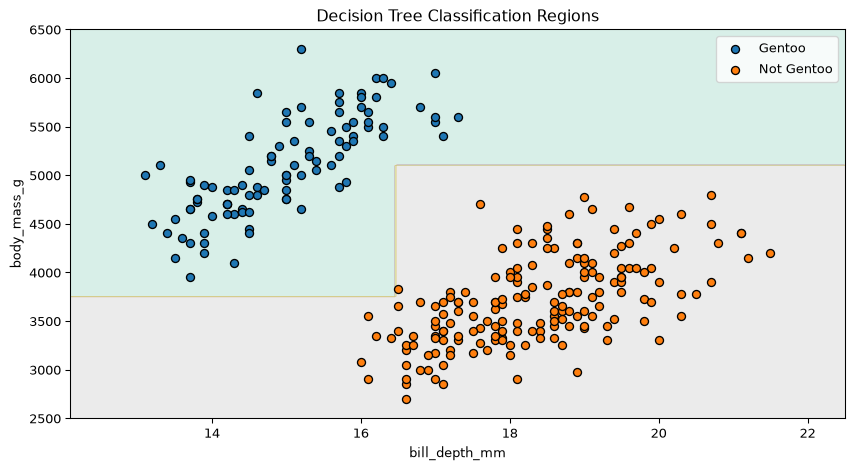

In [12]:
def plot_decision_boundary(X, y, model, feature_names):
    x0 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300)
    x1 = np.linspace(X[:, 1].min() - 200, X[:, 1].max() + 200, 300)
    xx0, xx1 = np.meshgrid(x0, x1)

    grid = np.column_stack([xx0.ravel(), xx1.ravel()])
    regions = np.argmax(
        model.predict_proba(grid), axis=1
    ).reshape(xx0.shape)

    plt.figure(figsize=(9, 5))
    plt.contourf(xx0, xx1, regions, alpha=0.25, cmap="Set2")
    for label in model.classes_:
        selected = y == label
        plt.scatter(
            X[selected, 0],
            X[selected, 1],
            edgecolor="black",
            label=label,
        )
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("Decision Tree Classification Regions")
    plt.legend()
    plt.tight_layout()


plot_decision_boundary(X_train, y_train, tree_model, feature_names)
plt.show()

# Complexity and Limitations

At a node containing $n$ examples and $D$ features, this implementation
tests up to $D(n-1)$ thresholds. Each test scans the examples again, so
finding one split is approximately $\mathcal{O}(Dn^2)$. Production
implementations reuse sorted values and sufficient statistics to avoid
much of this work.

Other important limitations include:

- only numerical features and binary threshold splits are supported;
- the greedy search does not guarantee a globally optimal tree;
- no missing-value strategy, sample weights, or pruning are implemented;
  and
- small changes to the training data can produce a different tree.

# Suggested Experiments

1.  Change `max_depth` and inspect the learned rules and decision
    regions.
2.  Change `min_samples_leaf` and observe which small regions disappear.
3.  Use all three species instead of the binary target.
4.  Add another numerical feature. The classifier will still work,
    although the decision regions can no longer be displayed in a
    two-dimensional plot.
5.  Compare the predictions with scikit-learn’s `DecisionTreeClassifier`
    using `criterion="entropy"`.